#📚 Importación de librerías

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#📌 Extracción

In [13]:
api = 'https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json'
raw_data = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json'


In [14]:
pd.read_json(raw_data)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


#🔧 Transformación

In [15]:
datos = pd.read_json(raw_data)
df = pd.json_normalize(datos.to_dict(orient='records'), sep='_')
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [16]:
columnas = datos.columns.tolist()

In [17]:
for col in df.columns:
    print (f'{col}: {df[col].isna().sum()} datos nulos')

customerID: 0 datos nulos
Churn: 0 datos nulos
customer_gender: 0 datos nulos
customer_SeniorCitizen: 0 datos nulos
customer_Partner: 0 datos nulos
customer_Dependents: 0 datos nulos
customer_tenure: 0 datos nulos
phone_PhoneService: 0 datos nulos
phone_MultipleLines: 0 datos nulos
internet_InternetService: 0 datos nulos
internet_OnlineSecurity: 0 datos nulos
internet_OnlineBackup: 0 datos nulos
internet_DeviceProtection: 0 datos nulos
internet_TechSupport: 0 datos nulos
internet_StreamingTV: 0 datos nulos
internet_StreamingMovies: 0 datos nulos
account_Contract: 0 datos nulos
account_PaperlessBilling: 0 datos nulos
account_PaymentMethod: 0 datos nulos
account_Charges_Monthly: 0 datos nulos
account_Charges_Total: 0 datos nulos


In [18]:
# Identificar filas duplicadas (donde todos los valores de las columnas son iguales)
filas_duplicadas= df[df.duplicated()]

# Mostrar el número de filas duplicadas
print(f"Número de filas duplicadas: {filas_duplicadas.shape[0]}")

Número de filas duplicadas: 0


In [19]:
print('Análisis de Valores Únicos por Columna en el DataFrame Normalizado (df):')
for col in df.columns:
    print(f'\n--- Columna: {col} ---')
    # Si la columna es categórica (tipo 'object') o tiene pocos valores únicos
    if df[col].dtype == 'object' or df[col].nunique() < 50:
        print('Valores únicos y sus conteos:')
        print(df[col].value_counts())
    # Si la columna es numérica y tiene muchos valores únicos
    else:
        print('Estadísticas descriptivas:')
        print(df[col].describe())

Análisis de Valores Únicos por Columna en el DataFrame Normalizado (df):

--- Columna: customerID ---
Valores únicos y sus conteos:
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7267, dtype: int64

--- Columna: Churn ---
Valores únicos y sus conteos:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

--- Columna: customer_gender ---
Valores únicos y sus conteos:
customer_gender
Male      3675
Female    3592
Name: count, dtype: int64

--- Columna: customer_SeniorCitizen ---
Valores únicos y sus conteos:
customer_SeniorCitizen
0    6085
1    1182
Name: count, dtype: int64

--- Columna: customer_Partner ---
Valores únicos y sus conteos:
customer_Partner
No     3749
Yes    3518
Name: count, dtype: int64

--- Columna: customer_Dependents ---
Valores únicos y sus conteos:
customer_Dependents
No     5086
Yes    2181

In [20]:
# Identificar los valores a reemplazar (el string vacío)
valor_a_reemplazar = ''

# Calcular la moda de la columna 'Churn', excluyendo el valor vacío
# Usamos .mode()[0] para obtener el primer valor si hay múltiples modos
moda_churn = df[df['Churn'] != valor_a_reemplazar]['Churn'].mode()[0]

# Reemplazar los valores vacíos con la moda
df['Churn'] = df['Churn'].replace(valor_a_reemplazar, moda_churn)

# Verificar los valores únicos después de la limpieza
print('Valores únicos de la columna Churn después de la limpieza:')
print(df['Churn'].value_counts())


Valores únicos de la columna Churn después de la limpieza:
Churn
No     5398
Yes    1869
Name: count, dtype: int64


#📊 Carga y análisis

In [21]:
print('Análisis Descriptivo General del DataFrame:')
# Aplicar describe() a todo el DataFrame para obtener estadísticas para columnas numéricas y categóricas
display(df.describe(include='all'))

print('\nAnálisis Descriptivo para Columnas Numéricas:')
# Filtrar solo columnas numéricas y aplicar describe()
display(df.select_dtypes(include=np.number).describe())

print('\nAnálisis Descriptivo para Columnas Categóricas:')
# Filtrar solo columnas categóricas y aplicar describe()
display(df.select_dtypes(include='object').describe())

Análisis Descriptivo General del DataFrame:


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
count,7267,7267,7267,7267.000000,7267,7267,7267.000000,7267,7267,7267,...,7267,7267,7267,7267,7267,7267,7267,7267,7267.000000,7267
unique,7267,2,2,NaN,2,2,NaN,2,3,3,...,3,3,3,3,3,3,2,4,NaN,6531
top,9995-HOTOH,No,Male,NaN,No,No,NaN,Yes,No,Fiber optic,...,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2
freq,1,5398,3675,NaN,3749,5086,NaN,6560,3495,3198,...,3182,3195,3582,2896,2870,4005,4311,2445,NaN,11
mean,NaN,NaN,NaN,0.162653,NaN,NaN,32.346498,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.720098,NaN
std,NaN,NaN,NaN,0.369074,NaN,NaN,24.571773,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.129572,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.425000,NaN
50%,NaN,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.300000,NaN
75%,NaN,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.875000,NaN



Análisis Descriptivo para Columnas Numéricas:


,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000



Análisis Descriptivo para Columnas Categóricas:


,customerID,Churn,customer_gender,customer_Partner,customer_Dependents,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Total
count,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267
unique,7267,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531
top,9995-HOTOH,No,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2
freq,1,5398,3675,3749,5086,6560,3495,3198,3608,3182,3195,3582,2896,2870,4005,4311,2445,11


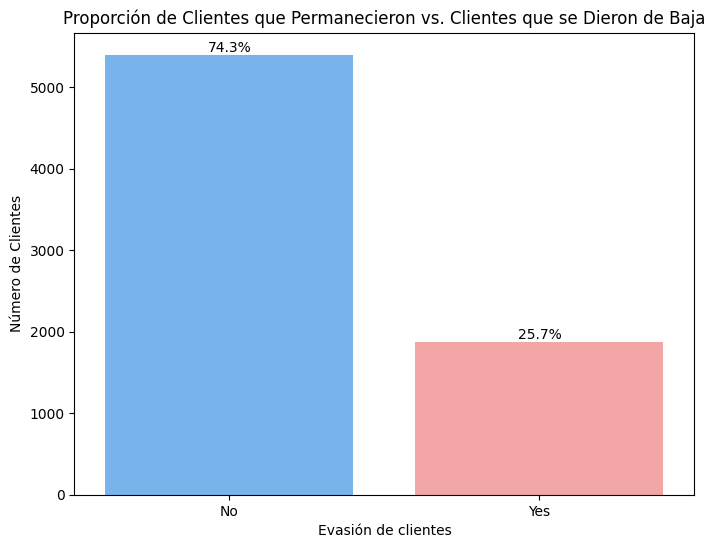

In [22]:
# Calcular las proporciones de Churn
churn_counts = df['Churn'].value_counts().reset_index()
churn_counts.columns = ['Churn', 'Count']

# Crear el gráfico de barras
plt.figure(figsize=(8, 6))
sns.barplot(x='Churn', y='Count', data=churn_counts, palette=['#66b3ff','#ff9999'], hue='Churn', legend=False)

# Añadir las etiquetas de porcentaje en las barras
total = churn_counts['Count'].sum()
for index, row in churn_counts.iterrows():
    plt.text(row.name, row.Count, f'{row.Count/total:.1%}', color='black', ha="center", va='bottom')

plt.title('Proporción de Clientes que Permanecieron vs. Clientes que se Dieron de Baja')
plt.xlabel('Evasión de clientes')
plt.ylabel('Número de Clientes')
plt.show()

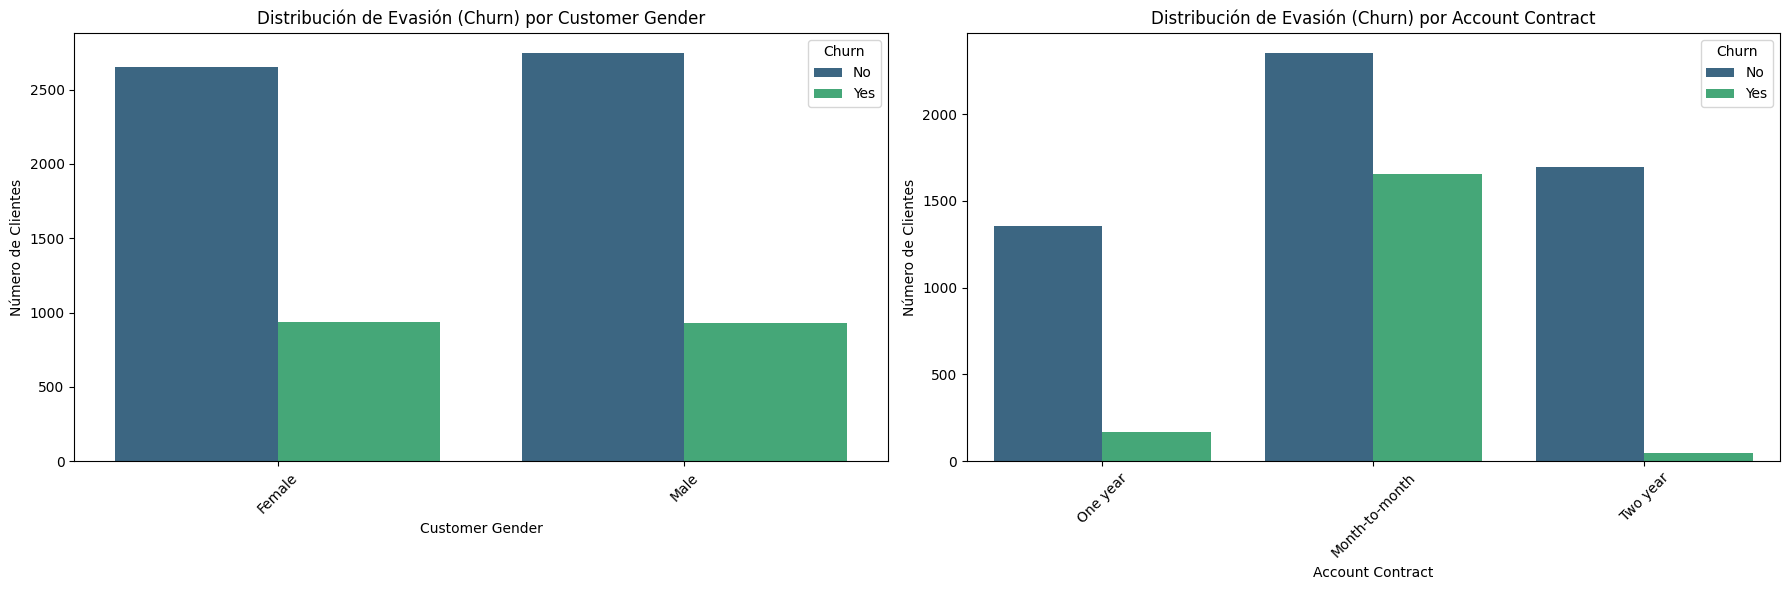

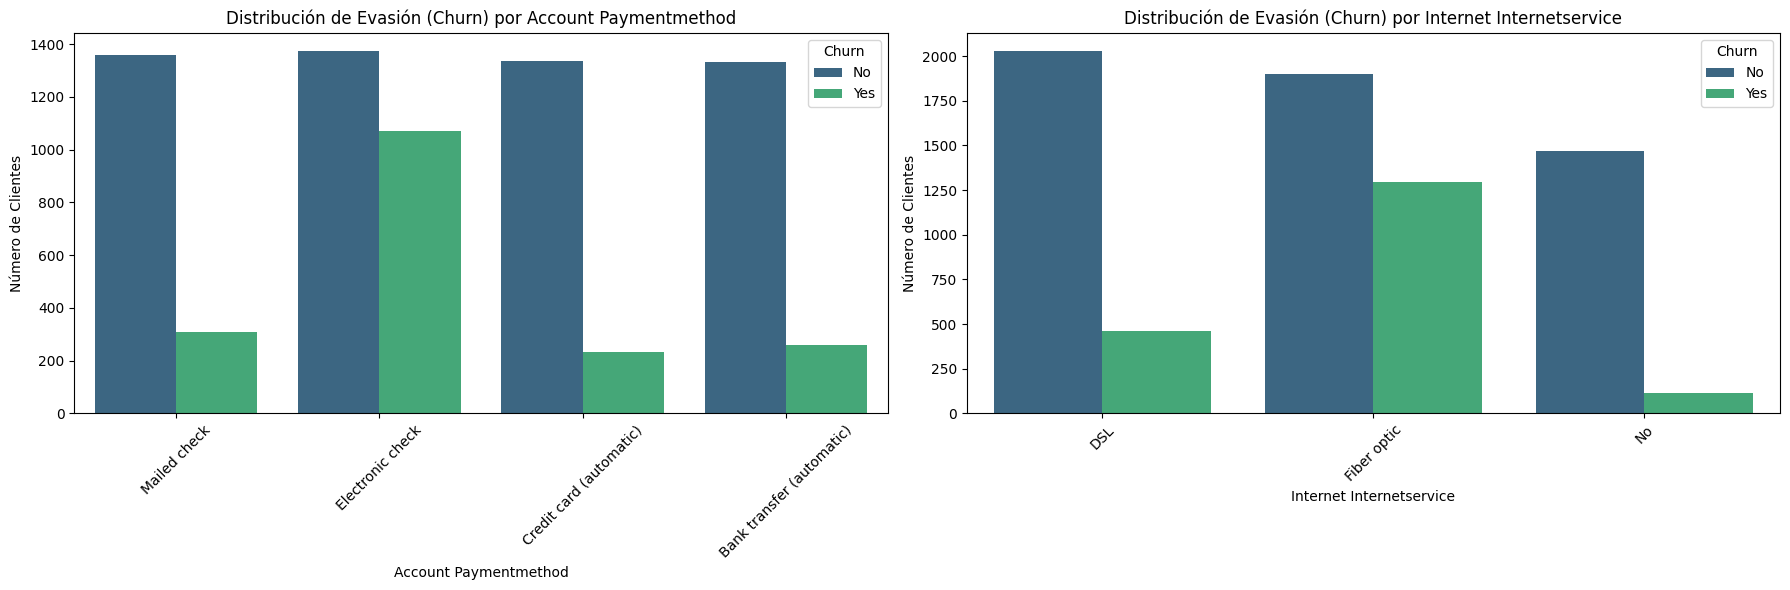

In [23]:
categorical_cols = [
    'customer_gender',
    'account_Contract',
    'account_PaymentMethod',
    'internet_InternetService'
]

# Iterar a través de las columnas en pares para generar dos gráficos a la vez
for i in range(0, len(categorical_cols), 2):
    fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # 1 fila, 2 columnas de subgráficos
    axes = axes.flatten() # Aplanar para facilitar el indexado, incluso si hay una sola fila/columna

    # Primer gráfico del par
    if i < len(categorical_cols):
        col1 = categorical_cols[i]
        ax1 = axes[0]
        sns.countplot(data=df, x=col1, hue='Churn', palette='viridis', ax=ax1)
        ax1.set_title(f'Distribución de Evasión (Churn) por {col1.replace("_", " ").title()}')
        ax1.set_xlabel(col1.replace("_", " ").title())
        ax1.set_ylabel('Número de Clientes')
        ax1.tick_params(axis='x', rotation=45)

        proportions_df1 = df.groupby(col1)['Churn'].value_counts(normalize=True).mul(100).rename('percent').reset_index()
        for container in ax1.containers:
            churn_value = container.get_label()
            for j, p in enumerate(container.patches):
                height = p.get_height()
                if pd.notna(height) and height > 0:
                    x_category = ax1.get_xticklabels()[j].get_text()
                    percentage_value = proportions_df1[
                        (proportions_df1[col1] == x_category) &
                        (proportions_df1['Churn'] == churn_value)
                    ]['percent'].values
                    if len(percentage_value) > 0:
                        percentage_text = '{:.1f}%'.format(percentage_value[0])
                        ax1.annotate(percentage_text,
                                    (p.get_x() + p.get_width() / 2., height),
                                    ha='center', va='bottom', fontsize=9, color='black')

    # Segundo gráfico del par, si existe
    if i + 1 < len(categorical_cols):
        col2 = categorical_cols[i+1]
        ax2 = axes[1]
        sns.countplot(data=df, x=col2, hue='Churn', palette='viridis', ax=ax2)
        ax2.set_title(f'Distribución de Evasión (Churn) por {col2.replace("_", " ").title()}')
        ax2.set_xlabel(col2.replace("_", " ").title())
        ax2.set_ylabel('Número de Clientes')
        ax2.tick_params(axis='x', rotation=45)

        proportions_df2 = df.groupby(col2)['Churn'].value_counts(normalize=True).mul(100).rename('percent').reset_index()
        for container in ax2.containers:
            churn_value = container.get_label()
            for j, p in enumerate(container.patches):
                height = p.get_height()
                if pd.notna(height) and height > 0:
                    x_category = ax2.get_xticklabels()[j].get_text()
                    percentage_value = proportions_df2[
                        (proportions_df2[col2] == x_category) &
                        (proportions_df2['Churn'] == churn_value)
                    ]['percent'].values
                    if len(percentage_value) > 0:
                        percentage_text = '{:.1f}%'.format(percentage_value[0])
                        ax2.annotate(percentage_text,
                                    (p.get_x() + p.get_width() / 2., height),
                                    ha='center', va='bottom', fontsize=9, color='black')
    else:
        # Si hay un número impar de columnas, oculta el segundo subgráfico vacío
        fig.delaxes(axes[1])

    plt.tight_layout()
    plt.show()

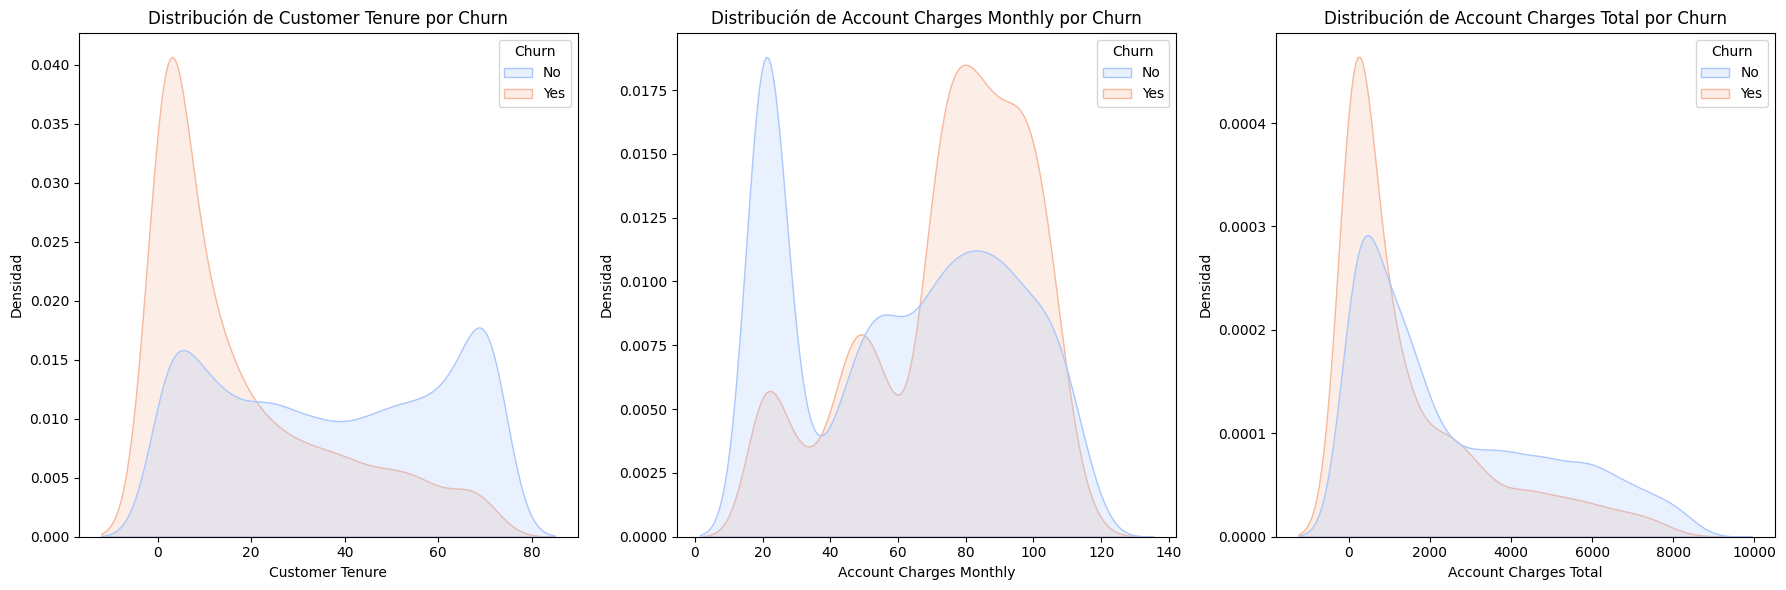

/tmp/ipykernel_268/3784231821.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='coolwarm')
/tmp/ipykernel_268/3784231821.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='coolwarm')
/tmp/ipykernel_268/3784231821.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y=col, palette='coolwarm')


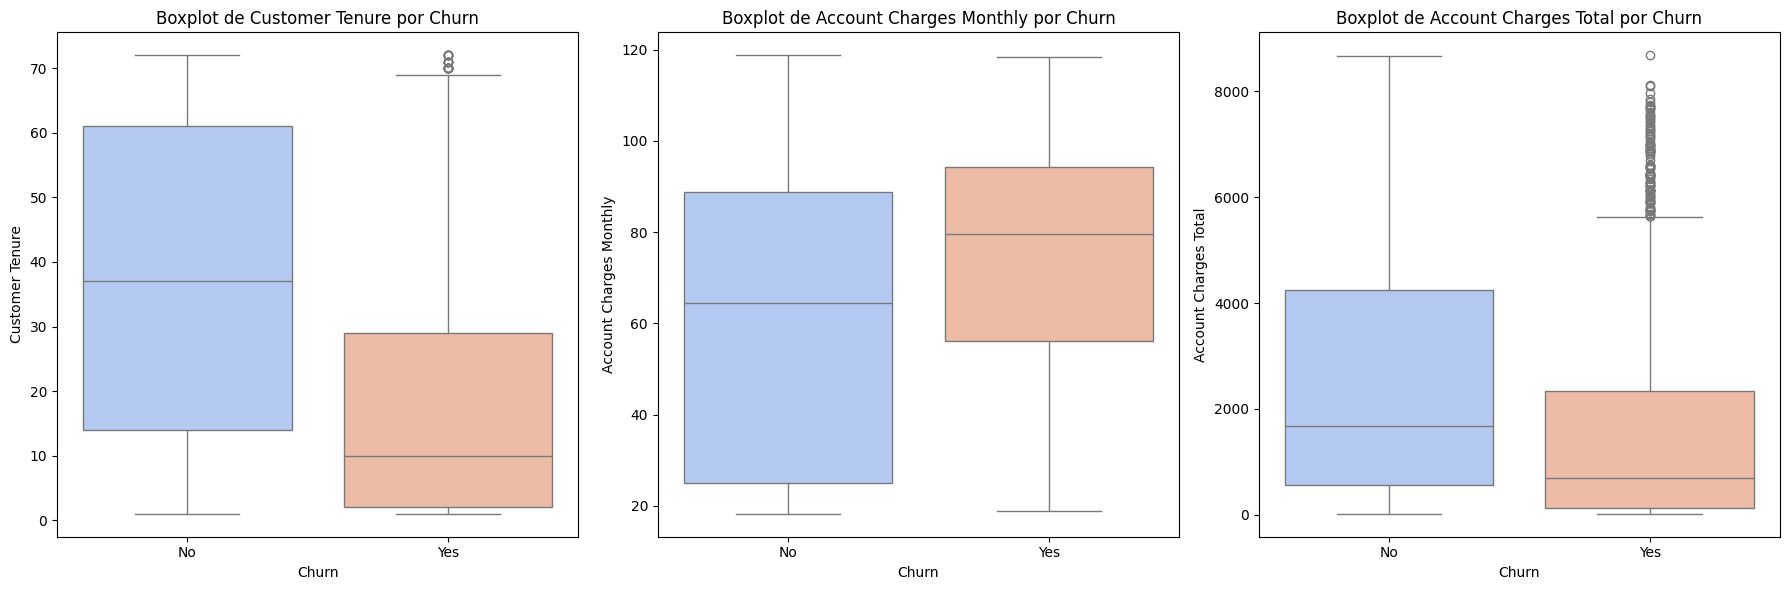

In [24]:
numerical_cols = [
    'customer_tenure',
    'account_Charges_Monthly',
    'account_Charges_Total'
]

# Convertir 'account_Charges_Total' a tipo numérico, manejando posibles errores
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

# Eliminar cualquier fila donde 'account_Charges_Total' se haya convertido a NaN
# (si los valores no numéricos se convirtieron a NaN en el paso anterior)
df.dropna(subset=['account_Charges_Total'], inplace=True)


plt.figure(figsize=(18, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, common_norm=False, palette='coolwarm')
    plt.title(f'Distribución de {col.replace("_", " ").title()} por Churn')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Densidad')

plt.tight_layout()
plt.show()

# Opcional: También se pueden usar boxplots para ver medianas y cuartiles
plt.figure(figsize=(18, 6))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x='Churn', y=col, palette='coolwarm')
    plt.title(f'Boxplot de {col.replace("_", " ").title()} por Churn')
    plt.xlabel('Churn')
    plt.ylabel(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

#📄Informe final